In [9]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv('winequality-red.csv')
df.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


In [14]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1599 entries, 0 to 1598
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1599 non-null   float64
 1   volatile acidity      1599 non-null   float64
 2   citric acid           1599 non-null   float64
 3   residual sugar        1599 non-null   float64
 4   chlorides             1599 non-null   float64
 5   free sulfur dioxide   1599 non-null   float64
 6   total sulfur dioxide  1599 non-null   float64
 7   density               1599 non-null   float64
 8   pH                    1599 non-null   float64
 9   sulphates             1599 non-null   float64
 10  alcohol               1599 non-null   float64
 11  quality               1599 non-null   int64  
dtypes: float64(11), int64(1)
memory usage: 150.0 KB


In [16]:
df.isnull().sum()


fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
dtype: int64

In [12]:
'''
1.Hər sütun üzrə outlier dəyərlərin sayını tapın

2.alcohol sütununda outliersləri müəyyən edin və upper_limit , lower_limit  dəyərləri göstərin

3.Outlierləri uyğun dəyərlə əvəz edin(Üst həddən yuxarı olan dəyərləri üst hədlə əvəzləyirik  , Aşağı həddən aşağı olan dəyərləri aşağı hədlə əvəzləyirik)

4. 

       ID	Name	Age
        1	Alice	25
        2	Bob	30
        3	Charlie	65
       4	David	40




ID	   City	                  Salary
3	New York	          70000
4	Los Angeles	          80000
5	Chicago	                  90000
6	Houston	                  100000


Bu dataframedəki bütün işçilər üzrə məlumatları göstərən join tətbiq edin.
Isciler uzre verilmeyen bezi melumatlar NaN olaraq görünməlidir.

5.Yalnız maaşı 80000-dən çox olan işçilərin məlumatları:

6. Yasi ortalama yaşdan boyuk olan və maaşı ortalama maaşdan kiçik olan işçilərin siyahısını göstərin


'''



'\n1.Hər sütun üzrə outlier dəyərlərin sayını tapın\n\n2.alcohol sütununda outliersləri müəyyən edin və upper_limit , lower_limit  dəyərləri göstərin\n\n3.Outlierləri uyğun dəyərlə əvəz edin(Üst həddən yuxarı olan dəyərləri üst hədlə əvəzləyirik  , Aşağı həddən aşağı olan dəyərləri aşağı hədlə əvəzləyirik)\n\n4. \n\n       ID\tName\tAge\n        1\tAlice\t25\n        2\tBob\t30\n        3\tCharlie\t65\n       4\tDavid\t40\n\n\n\n\nID\t   City\t                  Salary\n3\tNew York\t          70000\n4\tLos Angeles\t          80000\n5\tChicago\t                  90000\n6\tHouston\t                  100000\n\n\nBu dataframedəki bütün işçilər üzrə məlumatları göstərən join tətbiq edin.\nIsciler uzre verilmeyen bezi melumatlar NaN olaraq görünməlidir.\n\n5.Yalnız maaşı 80000-dən çox olan işçilərin məlumatları:\n\n6. Yasi ortalama yaşdan boyuk olan və maaşı ortalama maaşdan kiçik olan işçilərin siyahısını göstərin\n\n\n'

In [33]:
df.columns

Index(['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar',
       'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density',
       'pH', 'sulphates', 'alcohol', 'quality'],
      dtype='object')

np.int64(49)

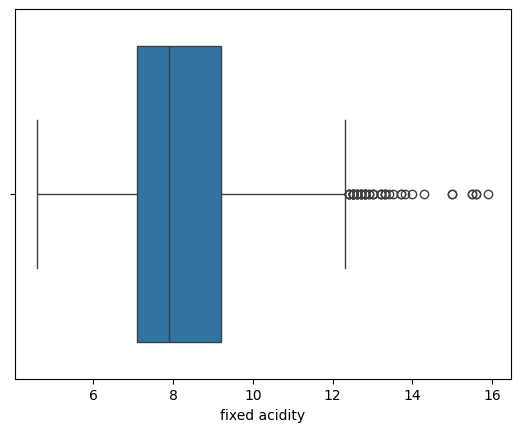

In [32]:
q1 = np.quantile(df["fixed acidity"], 0.25)
q3 = np.quantile(df["fixed acidity"], 0.75)
iqr = q3 - q1 
minn = q1 - 1.5* iqr
maxx = q3 + 1.5 *iqr
sns.boxplot(data = df , x = "fixed acidity")



countt = ((df['fixed acidity'] < minn) | (df['fixed acidity'] > maxx)).sum()

countt

np.int64(19)

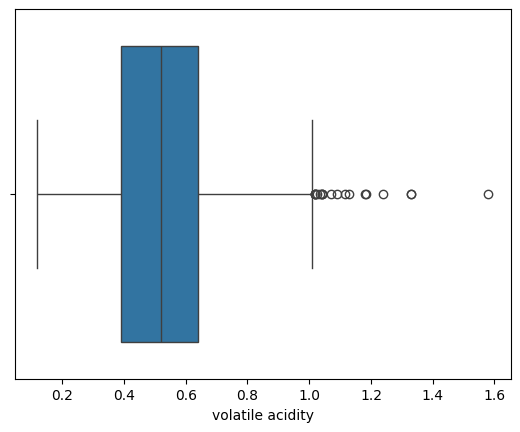

In [34]:
q1 = np.quantile(df["volatile acidity"], 0.25)
q3 = np.quantile(df["volatile acidity"], 0.75)
iqr = q3 - q1 
minn = q1 - 1.5* iqr
maxx = q3 + 1.5 *iqr
sns.boxplot(data = df , x = "volatile acidity")



countt = ((df['volatile acidity'] < minn) | (df['volatile acidity'] > maxx)).sum()

countt

In [39]:
countt={}
for i in df.select_dtypes(include='number').columns:
    q1 = np.quantile(df[i], 0.25)
    q3 = np.quantile(df[i], 0.75)
    iqr = q3 - q1 
    minn = q1 - 1.5* iqr
    maxx = q3 + 1.5 *iqr

    
    countt[i] = ((df[i] < minn) | (df[i] > maxx)).sum()

countt

{'fixed acidity': np.int64(49),
 'volatile acidity': np.int64(19),
 'citric acid': np.int64(1),
 'residual sugar': np.int64(155),
 'chlorides': np.int64(112),
 'free sulfur dioxide': np.int64(30),
 'total sulfur dioxide': np.int64(55),
 'density': np.int64(45),
 'pH': np.int64(35),
 'sulphates': np.int64(59),
 'alcohol': np.int64(13),
 'quality': np.int64(28)}

7.1000000000000005
13.5


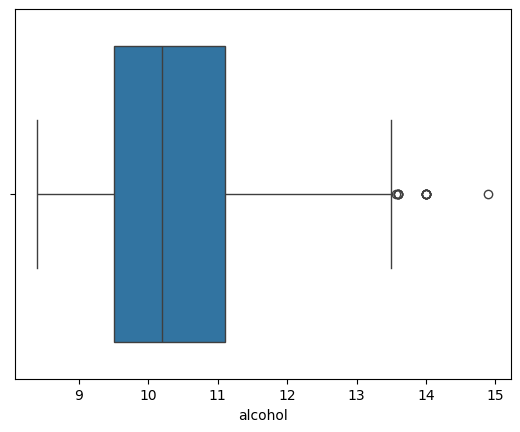

In [43]:
#2.alcohol sütununda outliersləri müəyyən edin və upper_limit , lower_limit  dəyərləri göstərin

q1 = np.quantile(df["alcohol"], 0.25)
q3 = np.quantile(df["alcohol"], 0.75)
iqr = q3 - q1 
minn = q1 - 1.5* iqr
maxx = q3 + 1.5 *iqr
sns.boxplot(data = df , x = "alcohol")


print(minn)
print(maxx)

In [49]:
#3.Outlierləri uyğun dəyərlə əvəz edin(Üst həddən yuxarı olan dəyərləri üst hədlə əvəzləyirik 
#, Aşağı həddən aşağı olan dəyərləri aşağı hədlə əvəzləyirik)

#df[df['alcohol']<minn].fillna(minn, inplace=True)


#df.loc[df['alcohol'] > maxx,'alcohol'] = maxx
df.loc[df['alcohol'] <minn,'alcohol'] = minn


7.1000000000000005
13.5


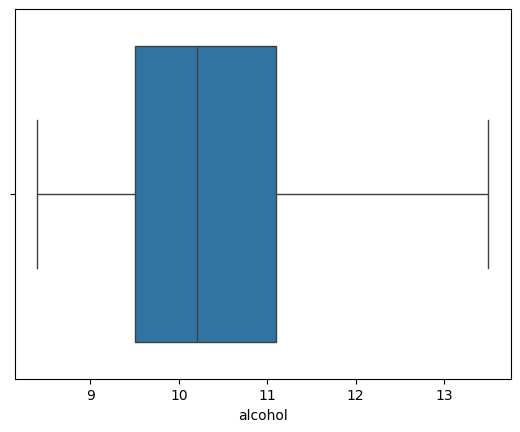

In [50]:

q1 = np.quantile(df["alcohol"], 0.25)
q3 = np.quantile(df["alcohol"], 0.75)
iqr = q3 - q1 
minn = q1 - 1.5* iqr
maxx = q3 + 1.5 *iqr
sns.boxplot(data = df , x = "alcohol")


print(minn)
print(maxx)

In [56]:
df1 = pd.DataFrame({
    'ID': [1, 2, 3, 4],
    'Name': ['Alice', 'Bob', 'Charlie', 'David'],
    'Age': [25, 30, 65, 40]
})

In [57]:
df2 = pd.DataFrame({
    'ID': [3, 4, 5, 6],
    'City': ['New York', 'Los Angeles', 'Chicago', 'Houston'],
    'Salary': [70000, 80000, 90000, 100000]
})

In [63]:
#Bu dataframedəki bütün işçilər üzrə məlumatları göstərən join tətbiq edin.
#Isciler uzre verilmeyen bezi melumatlar NaN olaraq görünməlidir.
full=pd.merge(df1, df2, on='ID', how='outer')
full

,ID,Name,Age,City,Salary
0,1,Alice,25.0,NaN,NaN
1,2,Bob,30.0,NaN,NaN
2,3,Charlie,65.0,New York,70000.0
3,4,David,40.0,Los Angeles,80000.0
4,5,NaN,NaN,Chicago,90000.0
5,6,NaN,NaN,Houston,100000.0


In [65]:
#5.Yalnız maaşı 80000-dən çox olan işçilərin məlumatları:
full[full["Salary"]>80000]


,ID,Name,Age,City,Salary
4,5,NaN,NaN,Chicago,90000.0
5,6,NaN,NaN,Houston,100000.0


In [67]:
#6. Yasi ortalama yaşdan boyuk olan və maaşı ortalama maaşdan kiçik olan işçilərin siyahısını göstərin

full[(full["Age"]>full["Age"].mean())&(full["Salary"]<full["Salary"].mean())] 


,ID,Name,Age,City,Salary
2,3,Charlie,65.0,New York,70000.0
